Data Loading & Preliminary Inspection


In [1]:
# Import essential system and data manipulation libraries
import os
import pandas as pd
import numpy as np

# Configure data visualizations libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress warnings to maintain clean presentation output
warnings.filterwarnings('ignore')

# Import machine learning model selection and evaluation metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pickle

# Setup visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

# Import HTML rendering support for IPython display outputs
try:
    from IPython.display import display
except ImportError:
    display = print

print("  Libraries imported successfully!")

  Libraries imported successfully!


In [3]:
# Configure dataset source location with fallback paths
csv_path = 'it_security_iot_botnet_ddos_detection_80k.csv'
if not os.path.exists(csv_path):
    csv_path = r'c:\Users\akumalla.jahnavi.EXAFLUENCE-INC\Desktop\1234567\it_security_iot_botnet_ddos_detection_80k.csv'
# Load raw network security logs
df = pd.read_csv(csv_path)

print(f"Dataset successfully loaded")
print(f" Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Column Names:\n{df.columns.tolist()}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n Missing Values:\n{df.isnull().sum().sum()} total null values")
print(f"\n First 5 Rows:")
display(df.head())

Dataset successfully loaded
 Dimensions: 80,000 rows × 9 columns

 Column Names:
['Device_ID', 'Device_Category', 'Outbound_Packets_Sec', 'Avg_Packet_Size_Bytes', 'Unique_Dest_IPs', 'Device_CPU_Usage_Pct', 'Calculated_Botnet_Score', 'Threat_Classification', 'Is_Compromised_Label']

 Data Types:
Device_ID                   object
Device_Category             object
Outbound_Packets_Sec       float64
Avg_Packet_Size_Bytes      float64
Unique_Dest_IPs              int64
Device_CPU_Usage_Pct       float64
Calculated_Botnet_Score    float64
Threat_Classification       object
Is_Compromised_Label         int64
dtype: object

 Missing Values:
0 total null values

 First 5 Rows:


,Device_ID,Device_Category,Outbound_Packets_Sec,Avg_Packet_Size_Bytes,Unique_Dest_IPs,Device_CPU_Usage_Pct,Calculated_Botnet_Score,Threat_Classification,Is_Compromised_Label
0,IOT_DEV_000001,Plug_Switch,2.47,584.9,3,23.8,0.0,SAFE_Benign_Activity,0
1,IOT_DEV_000002,Plug_Switch,3.14,593.3,2,20.6,0.0,SAFE_Benign_Activity,0
2,IOT_DEV_000003,Plug_Switch,0.79,347.0,1,6.1,0.0,SAFE_Benign_Activity,0
3,IOT_DEV_000004,Plug_Switch,4.36,456.0,5,20.9,0.0,SAFE_Benign_Activity,0
4,IOT_DEV_000005,Plug_Switch,4.10,545.6,2,24.3,0.0,SAFE_Benign_Activity,0


In [4]:
# Print descriptive statistics summary for categorical and numerical features
print("Statistical Summary:")
display(df.describe(include='all'))

Statistical Summary:


,Device_ID,Device_Category,Outbound_Packets_Sec,Avg_Packet_Size_Bytes,Unique_Dest_IPs,Device_CPU_Usage_Pct,Calculated_Botnet_Score,Threat_Classification,Is_Compromised_Label
count,80000,80000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000,80000.000000
unique,80000,3,NaN,NaN,NaN,NaN,NaN,3,NaN
top,IOT_DEV_079984,Plug_Switch,NaN,NaN,NaN,NaN,NaN,SAFE_Benign_Activity,NaN
freq,1,26729,NaN,NaN,NaN,NaN,NaN,78158,NaN
mean,NaN,NaN,18.080284,487.543018,2.949100,17.001013,2.103905,NaN,0.029575
std,NaN,NaN,84.402469,120.243602,1.439648,12.709981,12.197385,NaN,0.169413
min,NaN,NaN,0.020000,65.600000,1.000000,5.000000,0.000000,NaN,0.000000
25%,NaN,NaN,2.940000,424.600000,2.000000,10.200000,0.000000,NaN,0.000000
50%,NaN,NaN,5.180000,496.400000,3.000000,15.400000,0.000000,NaN,0.000000
75%,NaN,NaN,8.440000,564.800000,4.000000,20.500000,0.000000,NaN,0.000000


Exploratory Data Analysis (EDA)


In [5]:
# Display target variable distributions and average compromise baseline rate
print("Target Variable (Is_Compromised_Label) Distribution:")
print(df['Is_Compromised_Label'].value_counts())
print(f"\n Compromise Rate: {df['Is_Compromised_Label'].mean()*100:.2f}%")

Target Variable (Is_Compromised_Label) Distribution:
Is_Compromised_Label
0    77634
1     2366
Name: count, dtype: int64

 Compromise Rate: 2.96%


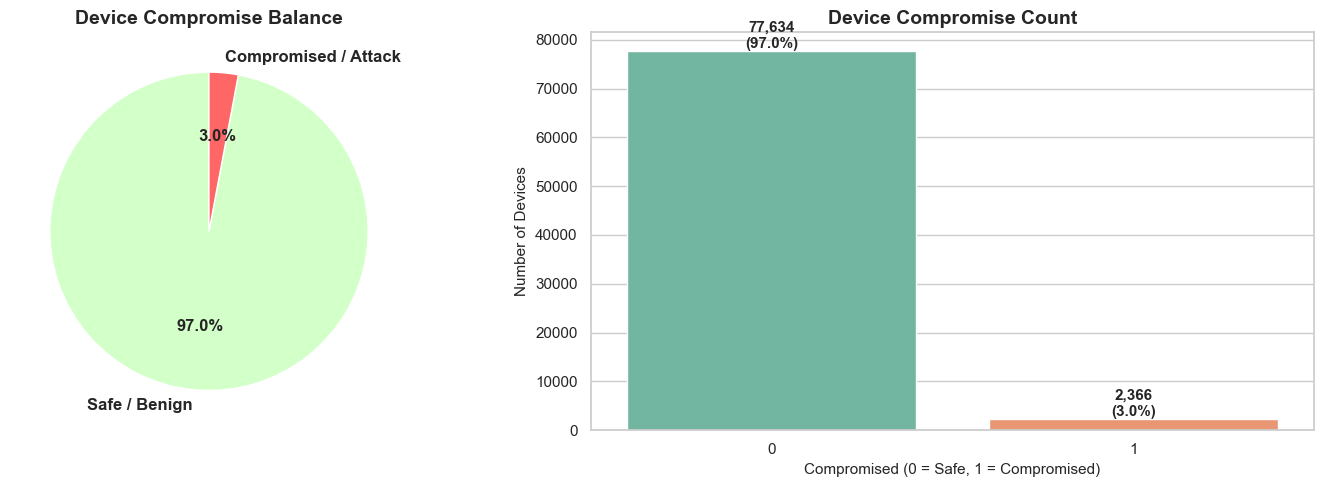

In [8]:
# Visual Plot: Plot target variable ratio balance and total frequencies
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot Pie chart of ground-truth classes
colors = ["#acff9985", '#ff6666']
compromised_counts = df['Is_Compromised_Label'].value_counts()
axes[0].pie(compromised_counts.values, labels=['Safe / Benign', 'Compromised / Attack'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Device Compromise Balance', fontsize=14, fontweight='bold')
# Plot count bars showing count annotations
sns.countplot(x='Is_Compromised_Label', hue='Is_Compromised_Label', data=df, palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Device Compromise Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Compromised (0 = Safe, 1 = Compromised)', fontsize=11)
axes[1].set_ylabel('Number of Devices', fontsize=11)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

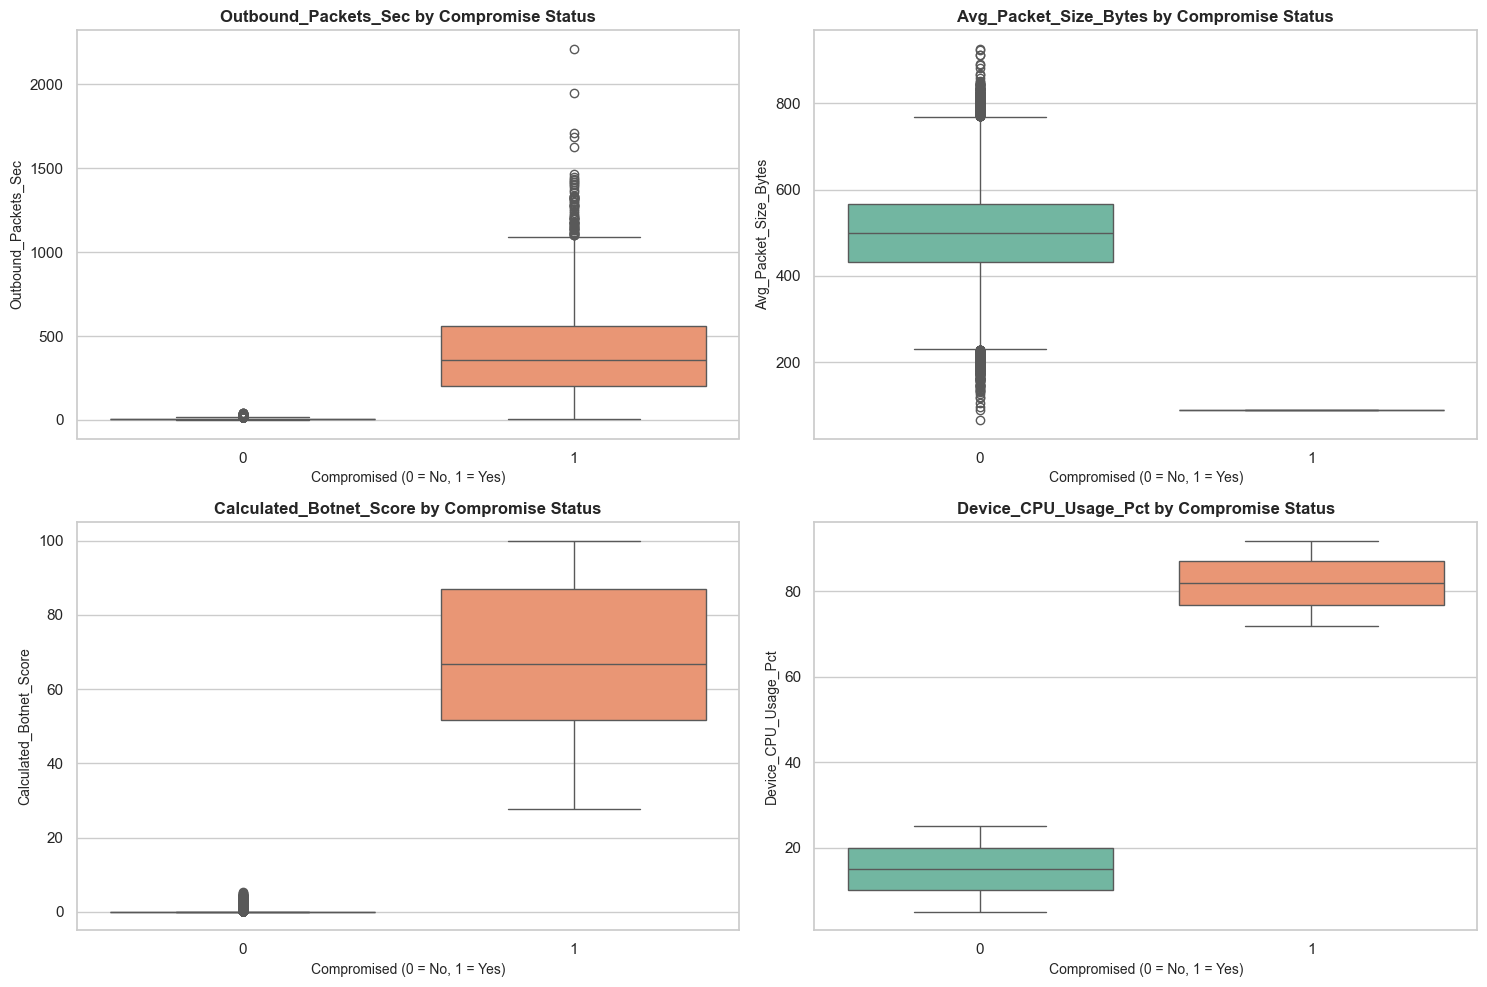

In [9]:
# Visual Plot: Generate boxplots for numerical telemetry metrics grouped by compromise labels
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features_to_plot = ['Outbound_Packets_Sec', 'Avg_Packet_Size_Bytes', 
                     'Calculated_Botnet_Score', 'Device_CPU_Usage_Pct']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x='Is_Compromised_Label', y=feature, hue='Is_Compromised_Label', data=df, palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{feature} by Compromise Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Compromised (0 = No, 1 = Yes)', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

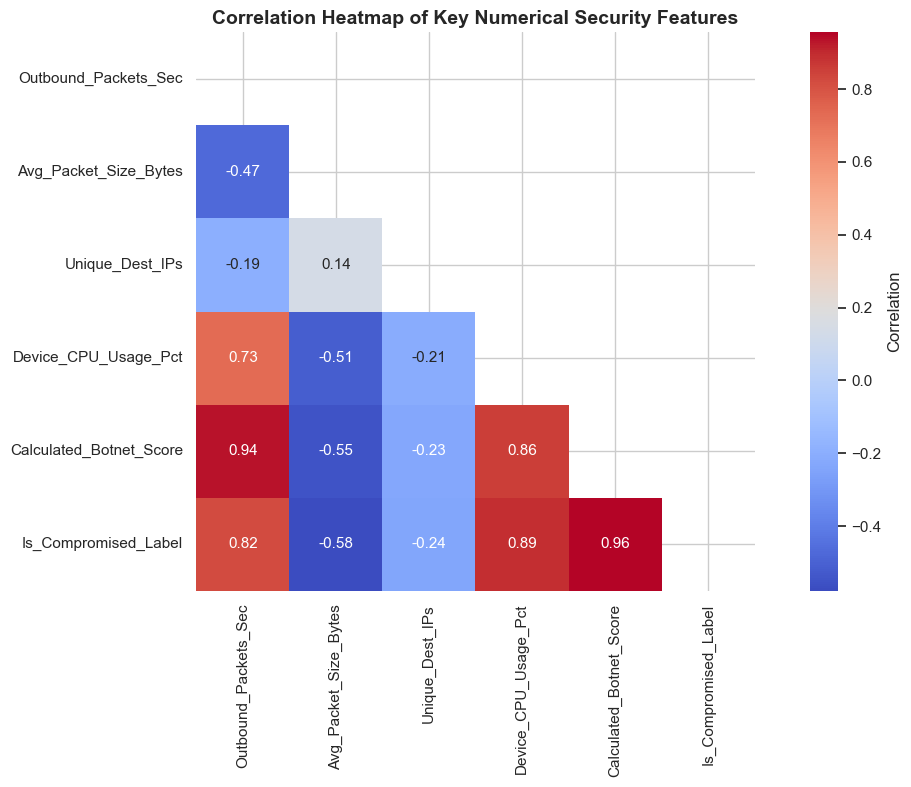

In [10]:
# Compute and visualize correlation matrix heatmap of numerical columns
numeric_cols = [
    'Outbound_Packets_Sec', 'Avg_Packet_Size_Bytes', 'Unique_Dest_IPs',
    'Device_CPU_Usage_Pct', 'Calculated_Botnet_Score', 'Is_Compromised_Label'
]

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Key Numerical Security Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

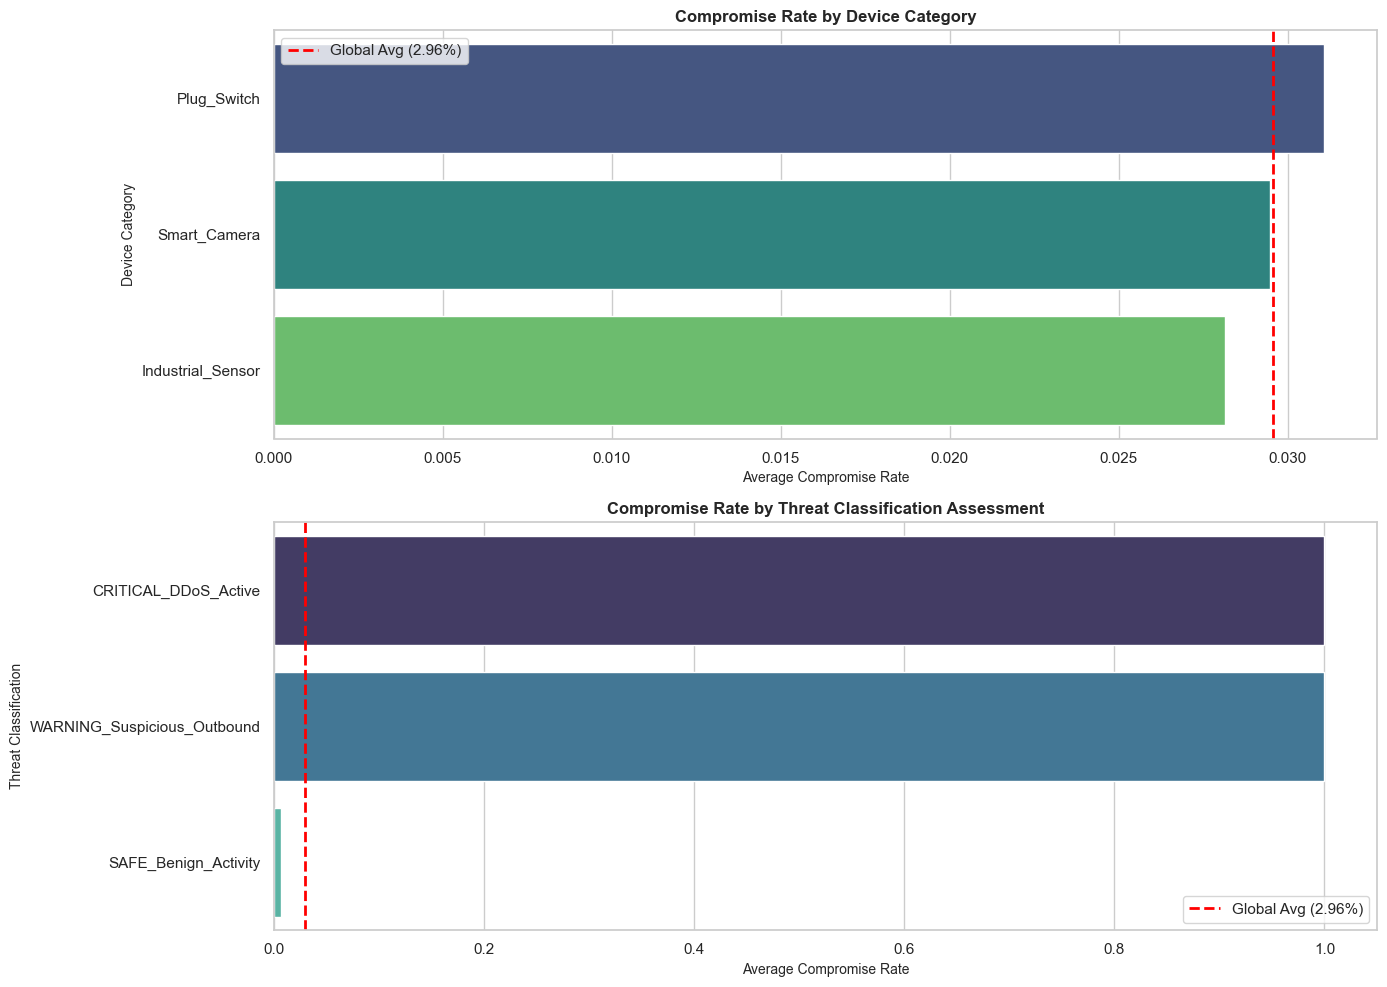

In [11]:
# Visual Plot: Render average device compromise rate comparisons grouped by categorical properties
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot compromise rates grouped by device category
dev_conv = df.groupby('Device_Category')['Is_Compromised_Label'].agg(['mean', 'count']).reset_index().sort_values(by='mean', ascending=False)
sns.barplot(x='mean', y='Device_Category', hue='Device_Category', data=dev_conv, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Compromise Rate by Device Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Compromise Rate', fontsize=10)
axes[0].set_ylabel('Device Category', fontsize=10)
axes[0].axvline(df['Is_Compromised_Label'].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Avg ({df["Is_Compromised_Label"].mean()*100:.2f}%)')
axes[0].legend()

# Plot compromise rates grouped by threat classification
threat_conv = df.groupby('Threat_Classification')['Is_Compromised_Label'].agg(['mean', 'count']).reset_index().sort_values(by='mean', ascending=False)
sns.barplot(x='mean', y='Threat_Classification', hue='Threat_Classification', data=threat_conv, palette='mako', ax=axes[1], legend=False)
axes[1].set_title('Compromise Rate by Threat Classification Assessment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Compromise Rate', fontsize=10)
axes[1].set_ylabel('Threat Classification', fontsize=10)
axes[1].axvline(df['Is_Compromised_Label'].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Avg ({df["Is_Compromised_Label"].mean()*100:.2f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

Preprocessing & Feature Engineering

In [12]:
# Sample records for analysis to optimize local execution footprint
df_processed = df.sample(n=min(10000, len(df)), random_state=42).copy()
print(f"Using {len(df_processed):,} records for model training and notebook execution.")

print("Engineering security-specific features...")
# Perform security-specific mathematical feature engineering
df_processed['packets_per_ip'] = df_processed['Outbound_Packets_Sec'] / (df_processed['Unique_Dest_IPs'] + 1)
df_processed['cpu_intensity_per_packet'] = df_processed['Device_CPU_Usage_Pct'] / (df_processed['Outbound_Packets_Sec'] + 1)
df_processed['network_bandwidth_est'] = df_processed['Outbound_Packets_Sec'] * df_processed['Avg_Packet_Size_Bytes']
df_processed['high_risk_device'] = (df_processed['Calculated_Botnet_Score'] > 50).astype(int)

print(" Feature engineering complete!")
print("   New features created: packets_per_ip, cpu_intensity_per_packet, network_bandwidth_est, high_risk_device")

Using 10,000 records for model training and notebook execution.
Engineering security-specific features...
 Feature engineering complete!
   New features created: packets_per_ip, cpu_intensity_per_packet, network_bandwidth_est, high_risk_device


In [14]:
# Perform feature selection by dropping identifier keys and training labels
X = df_processed.drop(columns=['Device_ID', 'Is_Compromised_Label'])
y = df_processed['Is_Compromised_Label']

# Segment input attributes into numerical and categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"  Features Prepared:")
print(f"   Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"   Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"   Total features: {len(numerical_cols) + len(categorical_cols)}")
print(f"   Target variable distribution:\n{y.value_counts()}")


  Features Prepared:
   Numerical features (9): ['Outbound_Packets_Sec', 'Avg_Packet_Size_Bytes', 'Unique_Dest_IPs', 'Device_CPU_Usage_Pct', 'Calculated_Botnet_Score', 'packets_per_ip', 'cpu_intensity_per_packet', 'network_bandwidth_est', 'high_risk_device']
   Categorical features (2): ['Device_Category', 'Threat_Classification']
   Total features: 11
   Target variable distribution:
Is_Compromised_Label
0    9684
1     316
Name: count, dtype: int64


In [15]:
# Split features and labels using stratified partition strategy (80/20 train-test split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Data Split Complete:")
print(f"   Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   Features per sample: {X_train.shape[1]}")
print(f"\n   Train set compromise rate: {y_train.mean()*100:.2f}%")
print(f"   Test set compromise rate:  {y_test.mean()*100:.2f}%")

  Data Split Complete:
   Train set: 8,000 samples (80.0%)
   Test set:  2,000 samples (20.0%)
   Features per sample: 11

   Train set compromise rate: 3.16%
   Test set compromise rate:  3.15%


In [16]:
# Construct ColumnTransformer object to preprocess columns:
# - Scale continuous variables using StandardScaler
# - Encode string labels using OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print("  Preprocessing pipeline built successfully!")

  Preprocessing pipeline built successfully!


Model Training & Comparison

In [19]:
from IPython.core import getipython
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Configure candidate classification models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# Define hyperparameter grid settings for tuning optimization
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0]
    },
    'Decision Tree': {
        'classifier__max_depth': [4, 6, 8, 10],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'classifier__n_estimators': [25, 50],
        'classifier__max_depth': [8, 12],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'classifier__n_estimators': [25, 50],
        'classifier__max_depth': [3, 6],
        'classifier__learning_rate': [0.05, 0.1, 0.2]
    }
}

results = []
trained_pipelines = {}
predictions_dict = {}

print("  Training Models with Hyperparameter Tuning (GridSearchCV)...\n")
for model_name, model in base_models.items():
    print(f"    Tuning {model_name}...")
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Search hyperparameters utilizing 3-Fold Cross-Validation targeting ROC-AUC metrics
    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grids[model_name],
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_
    trained_pipelines[model_name] = best_pipeline
    
    print(f"      Best Parameters: {grid_search.best_params_}")
    print(f"      Best CV ROC-AUC: {grid_search.best_score_:.4f}")
    
    # Compute output predictions on test partitions
    y_pred_model = best_pipeline.predict(X_test)
    y_pred_proba_model = best_pipeline.predict_proba(X_test)[:, 1]
    predictions_dict[model_name] = {'pred': y_pred_model, 'proba': y_pred_proba_model}
    
    # Evaluate and score performance parameters
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1-Score': f1_score(y_test, y_pred_model),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_model)
    })
print(f"    {model_name} completed\n")
# Format output metrics details inside sorted DataFrame layout
df_results_numeric = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
df_results = df_results_numeric.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_results[col] = df_results[col].map(lambda x: f"{x*100:.2f}%")
df_results['ROC-AUC'] = df_results['ROC-AUC'].map(lambda x: f"{x:.4f}")

print("\n Model Performance Results:")
display(df_results)

  Training Models with Hyperparameter Tuning (GridSearchCV)...

    Tuning Logistic Regression...
      Best Parameters: {'classifier__C': 0.1}
      Best CV ROC-AUC: 1.0000
    Tuning Decision Tree...
      Best Parameters: {'classifier__max_depth': 4, 'classifier__min_samples_split': 2}
      Best CV ROC-AUC: 1.0000
    Tuning Random Forest...
      Best Parameters: {'classifier__max_depth': 8, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 25}
      Best CV ROC-AUC: 1.0000
    Tuning XGBoost...
      Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 25}
      Best CV ROC-AUC: 1.0000
    XGBoost completed


 Model Performance Results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,100.00%,100.00%,100.00%,100.00%,1.0000
1,Decision Tree,100.00%,100.00%,100.00%,100.00%,1.0000
2,Random Forest,100.00%,100.00%,100.00%,100.00%,1.0000
3,XGBoost,99.95%,100.00%,98.41%,99.20%,1.0000


Model Evaluation & Metrics Comparison

In [20]:
# Print comparative metrics summary leaderboard
print("\n Model Performance Results:\n")
print(df_results.to_string(index=False))


 Model Performance Results:

              Model Accuracy Precision  Recall F1-Score ROC-AUC
Logistic Regression  100.00%   100.00% 100.00%  100.00%  1.0000
      Decision Tree  100.00%   100.00% 100.00%  100.00%  1.0000
      Random Forest  100.00%   100.00% 100.00%  100.00%  1.0000
            XGBoost   99.95%   100.00%  98.41%   99.20%  1.0000


In [21]:
# Select champion model based on top ROC-AUC scores
champion_name = df_results_numeric.loc[df_results_numeric['ROC-AUC'].idxmax(), 'Model']
champion_roc_auc = df_results_numeric.loc[df_results_numeric['Model'] == champion_name, 'ROC-AUC'].values[0]

print(f"\n CHAMPION MODEL: {champion_name}")
print(f"   ROC-AUC Score: {champion_roc_auc:.4f}")
print(f"\nThis model will be used for further threat scoring and security predictions.")


 CHAMPION MODEL: Logistic Regression
   ROC-AUC Score: 1.0000

This model will be used for further threat scoring and security predictions.


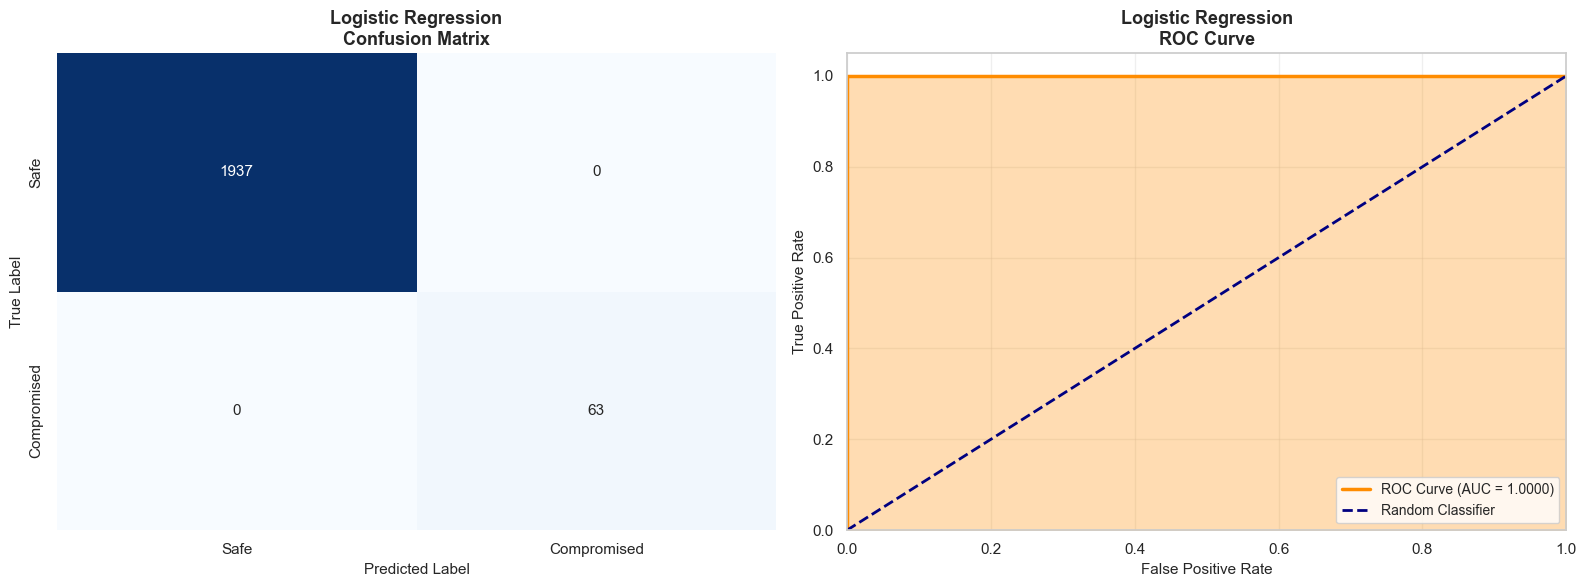

In [22]:
# Fetch champion pipeline outputs, predictions, and estimated probabilities
champion_pipeline = trained_pipelines[champion_name]
y_pred = predictions_dict[champion_name]['pred']
y_pred_proba = predictions_dict[champion_name]['proba']

# Plot Confusion Matrix and ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], 
            xticklabels=['Safe', 'Compromised'], yticklabels=['Safe', 'Compromised'])
axes[0].set_title(f'{champion_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title(f'{champion_name}\nROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Print detailed classification parameters report
print(f"\n DETAILED CLASSIFICATION REPORT - {champion_name}\n")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Compromised'], digits=4))


 DETAILED CLASSIFICATION REPORT - Logistic Regression

              precision    recall  f1-score   support

        Safe     1.0000    1.0000    1.0000      1937
 Compromised     1.0000    1.0000    1.0000        63

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



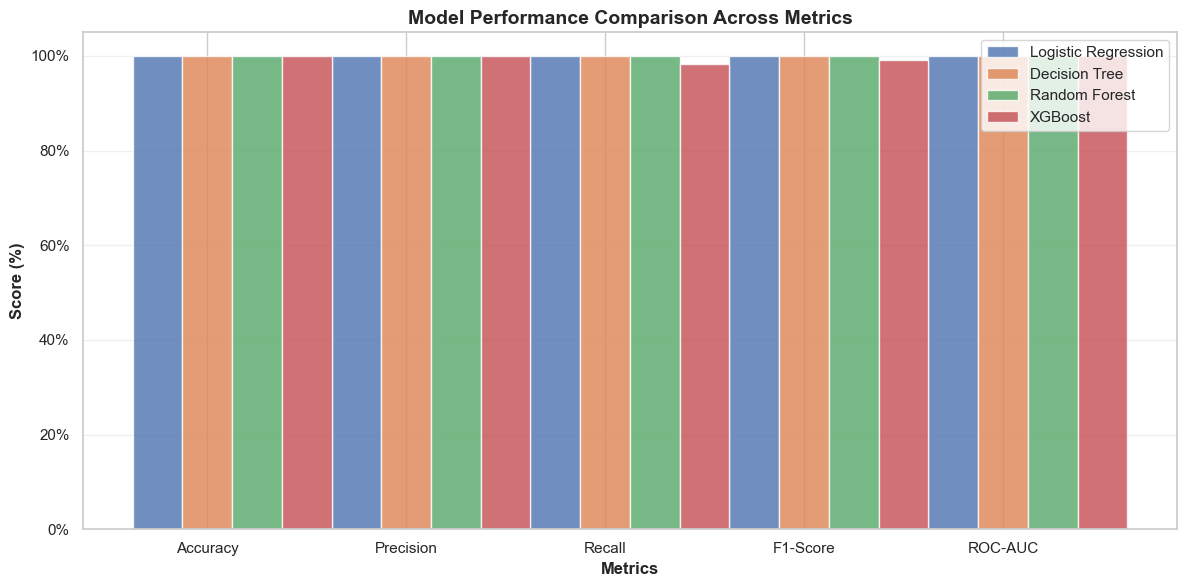

In [24]:
# Plot visual model comparison metrics across key performance indicators
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, model_name in enumerate(df_results_numeric['Model']):
    values = [float(df_results_numeric.loc[df_results_numeric['Model'] == model_name, m].values[0]) 
              for m in metrics]
    ax.bar(x + i*width, values, width, label=model_name, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Feature Importance & Security Insights


In [25]:
# Extract features importance variables using trained Random Forest configurations
print(" Extracting feature importances...")

rf_pipeline = trained_pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']
preprocessor_obj = rf_pipeline.named_steps['preprocessor']

# Unpack encoded categorical feature names
cat_features_encoded = preprocessor_obj.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_features_encoded

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Feature': [all_feature_names[i] for i in indices],
    'Importance': importances[indices]
})

print(" Feature importance extraction complete!")
print(f"\nTop 15 Most Important Security Features:")
display(df_importance.head(15))

 Extracting feature importances...
 Feature importance extraction complete!

Top 15 Most Important Security Features:


,Feature,Importance
0,Calculated_Botnet_Score,0.263835
1,Device_CPU_Usage_Pct,0.208031
2,Avg_Packet_Size_Bytes,0.199462
3,packets_per_ip,0.117969
4,Outbound_Packets_Sec,0.078422
5,Threat_Classification_SAFE_Benign_Activity,0.058144
6,network_bandwidth_est,0.030958
7,high_risk_device,0.028540
8,Threat_Classification_CRITICAL_DDoS_Active,0.010900
9,Unique_Dest_IPs,0.003740


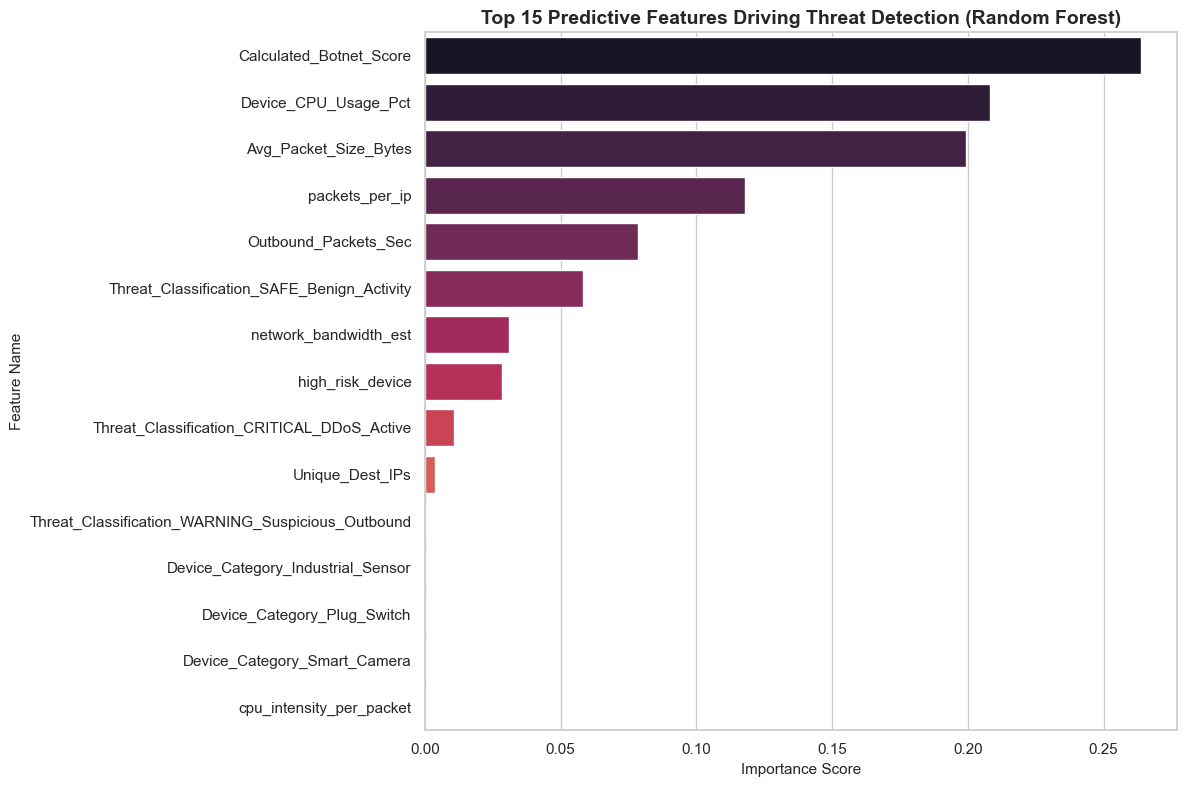

In [26]:
# Plot bar chart ranking the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_importance.head(15), palette='rocket', legend=False)
plt.title('Top 15 Predictive Features Driving Threat Detection (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)
plt.tight_layout()
plt.show()

Threat Scoring & Predictions

In [27]:
# Score entire dataset using the champion classifier model
scored_df = df_processed.copy()

all_scores = champion_pipeline.predict_proba(X)[:, 1]
all_predictions = champion_pipeline.predict(X)

scored_df['threat_score'] = all_scores
scored_df['predicted_compromise'] = all_predictions

# Bin threat probability outputs into risk categorization levels
scored_df['threat_category'] = pd.cut(
    scored_df['threat_score'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Threat', 'Medium Threat', 'High Threat'],
    include_lowest=True
)

print(" Threat Scoring Complete!\n")
print("Threat Score Distribution:")
print(f"   Mean: {scored_df['threat_score'].mean():.4f}")
print(f"   Median: {scored_df['threat_score'].median():.4f}")
print(f"   Min: {scored_df['threat_score'].min():.4f}")
print(f"   Max: {scored_df['threat_score'].max():.4f}")
print("\nThreat Category Distribution:")
print(scored_df['threat_category'].value_counts().sort_index())

 Threat Scoring Complete!

Threat Score Distribution:
   Mean: 0.0315
   Median: 0.0002
   Min: 0.0000
   Max: 1.0000

Threat Category Distribution:
threat_category
Low Threat       9684
Medium Threat       0
High Threat       316
Name: count, dtype: int64


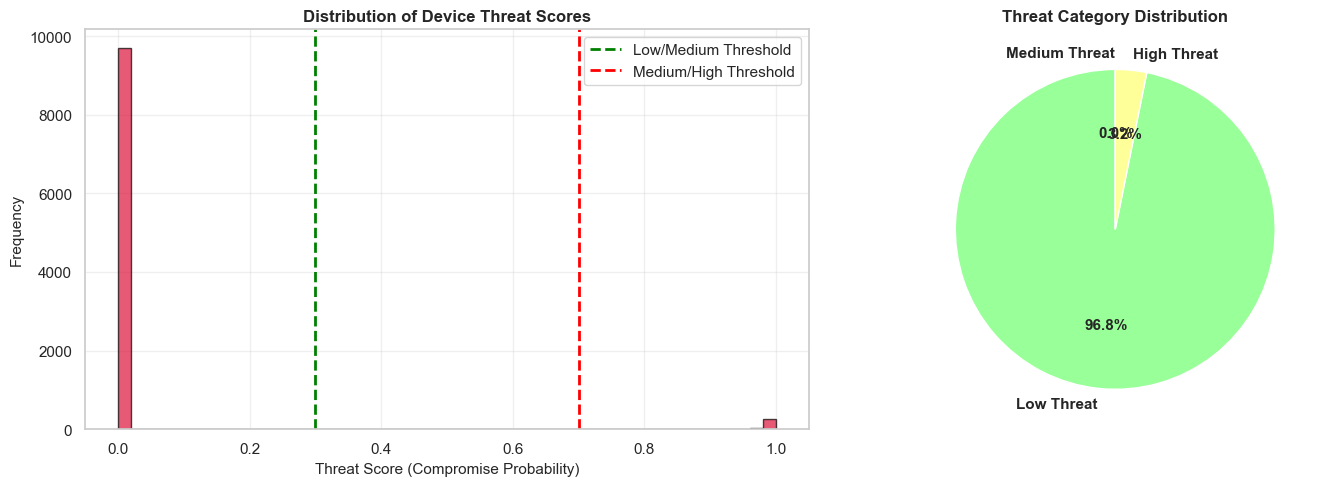

In [28]:
# Plot threat probability scores distribution and priority categorization levels
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(scored_df['threat_score'], bins=50, color='crimson', edgecolor='black', alpha=0.7)
axes[0].axvline(0.3, color='green', linestyle='--', linewidth=2, label='Low/Medium Threshold')
axes[0].axvline(0.7, color='red', linestyle='--', linewidth=2, label='Medium/High Threshold')
axes[0].set_title('Distribution of Device Threat Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Threat Score (Compromise Probability)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

priority_counts = scored_df['threat_category'].value_counts()
colors_priority = ["#99ff99", '#ffff99', "#ff9999"]
axes[1].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', 
            colors=colors_priority, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Threat Category Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# Filter out device lists identified as High Threat for priority security action
high_threat = scored_df[scored_df['threat_category'] == 'High Threat'].sort_values('threat_score', ascending=False)

high_threat = scored_df[scored_df['threat_category'] == 'High Threat'].sort_values('threat_score', ascending=False)

print(f"\n HIGH THREAT DEVICES (Top 10)\n")
print(f"Total High Threat Devices Found: {len(high_threat):,}")
print(f"\nTop 10 Devices to Quarantine:")
display_cols = ['Device_ID', 'Device_Category', 'Outbound_Packets_Sec', 'Calculated_Botnet_Score', 'threat_score', 'predicted_compromise']
display(high_threat[display_cols].head(10))


 HIGH THREAT DEVICES (Top 10)

Total High Threat Devices Found: 316

Top 10 Devices to Quarantine:


,Device_ID,Device_Category,Outbound_Packets_Sec,Calculated_Botnet_Score,threat_score,predicted_compromise
29460,IOT_DEV_029461,Plug_Switch,2209.71,100.0,1.0,1
36696,IOT_DEV_036697,Plug_Switch,1417.07,100.0,1.0,1
62739,IOT_DEV_062740,Industrial_Sensor,1429.11,100.0,1.0,1
25134,IOT_DEV_025135,Industrial_Sensor,1247.19,100.0,1.0,1
20944,IOT_DEV_020945,Plug_Switch,1325.97,100.0,1.0,1
5104,IOT_DEV_005105,Smart_Camera,1280.62,100.0,1.0,1
58456,IOT_DEV_058457,Smart_Camera,1321.72,100.0,1.0,1
32604,IOT_DEV_032605,Industrial_Sensor,1195.58,100.0,1.0,1
28396,IOT_DEV_028397,Plug_Switch,1113.73,100.0,1.0,1
42302,IOT_DEV_042303,Plug_Switch,1173.10,100.0,1.0,1


Notebook Prediction Engine


In [30]:
# Test the champion pipeline by making predictions on single mock telemetry query inputs
sample_new_device = X_test.iloc[[0]].copy()

sample_prediction = champion_pipeline.predict(sample_new_device)[0]
sample_probability = champion_pipeline.predict_proba(sample_new_device)[0][1]

print(" New Device Network Flow Analyzed")
print(f"Status: {'CRITICAL: Compromised' if sample_prediction == 1 else 'SAFE: Normal Activity'}")
print(f"Threat Score (Compromise Probability): {sample_probability:.4f}")

if sample_probability >= 0.70:
    priority = 'High Threat'
elif sample_probability >= 0.30:
    priority = 'Medium Threat'
else:
    priority = 'Low Threat'

print(f"Response Category: {priority}")
display(sample_new_device)

 New Device Network Flow Analyzed
Status: SAFE: Normal Activity
Threat Score (Compromise Probability): 0.0005
Response Category: Low Threat


,Device_Category,Outbound_Packets_Sec,Avg_Packet_Size_Bytes,Unique_Dest_IPs,Device_CPU_Usage_Pct,Calculated_Botnet_Score,Threat_Classification,packets_per_ip,cpu_intensity_per_packet,network_bandwidth_est,high_risk_device
60259,Smart_Camera,4.6,349.8,1,14.1,0.0,SAFE_Benign_Activity,2.3,2.517857,1609.08,0


Business Recommendations & Strategy


In [31]:
# Print comparative analytical summaries and response recommendation protocols
print("STRATEGIC IoT SECURITY RECOMMENDATIONS & ACTION PLAN")

print("\n KEY NETWORK SIGNATURES OF INFECTION:")
top_features = df_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']*100:.2f}% importance")

print("\n  COMPROMISE RATES BY DEVICE TYPE:")
cat_analysis = df.groupby('Device_Category')['Is_Compromised_Label'].agg(['mean', 'count']).round(4)
for cat in cat_analysis.index:
    conv_rate = cat_analysis.loc[cat, 'mean'] * 100
    count = int(cat_analysis.loc[cat, 'count'])
    print(f"   • {cat}: {conv_rate:.2f}% compromise rate ({count:,} monitored devices)")

print("\n  THREAT CLASSIFICATION ACCURACY:")
source_analysis = df.groupby('Threat_Classification')['Is_Compromised_Label'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for source in source_analysis.index:
    conv_rate = source_analysis.loc[source, 'mean'] * 100
    count = int(source_analysis.loc[source, 'count'])
    print(f"   • {source}: {conv_rate:.2f}% compromise rate ({count:,} events)")

print("\n QUARANTINE AND RESPONSE STRATEGY:")
high_count = len(scored_df[scored_df['threat_category'] == 'High Threat'])
medium_count = len(scored_df[scored_df['threat_category'] == 'Medium Threat'])
low_count = len(scored_df[scored_df['threat_category'] == 'Low Threat'])

print(f"   • High Threat Devices (Score > 0.70): {high_count:,} ({high_count/len(scored_df)*100:.2f}%) -> Immediate automated network isolation.")
print(f"   • Medium Threat Devices (0.30-0.70): {medium_count:,} ({medium_count/len(scored_df)*100:.2f}%) -> Schedule deep inspection and signature validation.")
print(f"   • Low Threat Devices (Score < 0.30): {low_count:,} ({low_count/len(scored_df)*100:.2f}%) -> Baseline monitoring and routine policy audits.")

print("\n CHAMPION DETECTOR PERFORMANCE:")
print(f"   • Champion Model: {champion_name}")
print(f"   • ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"   • Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"   • Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"   • Recall: {recall_score(y_test, y_pred)*100:.2f}%")
print(f"   • F1-Score: {f1_score(y_test, y_pred)*100:.2f}%")

print("\n IMMEDIATE ACTIONABLE PROTOCOLS:")
print("   Configure firewalls to automatically isolate devices categorized as HIGH THREAT.")
print("   Track outbound packets per second closely - it is the single most important network feature.")
print("   Audit CPU usage patterns; anomalous spikes relative to low traffic identify hidden malware execution.")
print("   Integrate the serialized champion_model.pkl in gateway routers for real-time traffic classification.")

STRATEGIC IoT SECURITY RECOMMENDATIONS & ACTION PLAN

 KEY NETWORK SIGNATURES OF INFECTION:
   • Calculated_Botnet_Score: 26.38% importance
   • Device_CPU_Usage_Pct: 20.80% importance
   • Avg_Packet_Size_Bytes: 19.95% importance
   • packets_per_ip: 11.80% importance
   • Outbound_Packets_Sec: 7.84% importance

  COMPROMISE RATES BY DEVICE TYPE:
   • Industrial_Sensor: 2.81% compromise rate (26,614 monitored devices)
   • Plug_Switch: 3.11% compromise rate (26,729 monitored devices)
   • Smart_Camera: 2.95% compromise rate (26,657 monitored devices)

  THREAT CLASSIFICATION ACCURACY:
   • CRITICAL_DDoS_Active: 100.00% compromise rate (639 events)
   • WARNING_Suspicious_Outbound: 100.00% compromise rate (1,203 events)
   • SAFE_Benign_Activity: 0.67% compromise rate (78,158 events)

 QUARANTINE AND RESPONSE STRATEGY:
   • High Threat Devices (Score > 0.70): 316 (3.16%) -> Immediate automated network isolation.
   • Medium Threat Devices (0.30-0.70): 0 (0.00%) -> Schedule deep inspect

Model Persistence & Export

In [32]:
# Save trained models, pipeline stats, and dataset calculations to disk
import joblib

model_path = 'champion_model.pkl'
joblib.dump(champion_pipeline, model_path)
print(f" Champion model saved: {model_path}")

results_path = 'model_results.csv'
df_results.to_csv(results_path, index=False)
print(f" Model results saved: {results_path}")

importance_path = 'feature_importance.csv'
df_importance.to_csv(importance_path, index=False)
print(f" Feature importance saved: {importance_path}")

scores_path = 'threat_scores.csv'
scored_df[['Device_ID', 'threat_score', 'predicted_compromise', 'threat_category']].to_csv(scores_path, index=False)
print(f" Threat scores saved: {scores_path}")

 Champion model saved: champion_model.pkl
 Model results saved: model_results.csv
 Feature importance saved: feature_importance.csv
 Threat scores saved: threat_scores.csv


In [33]:
# Output completion metrics and strategic advice log summary
print(" SECURITY ANALYTICS PIPELINE GENERATION COMPLETE!")
print("\n Output Files Generated:")
print(f"   1. champion_model.pkl - Trained ML pipeline for real-time predictions")
print(f"   2. model_results.csv - Comparison metrics of all candidate models")
print(f"   3. feature_importance.csv - Feature importance rankings")
print(f"   4. threat_scores.csv - Scored devices list with prioritized threat levels")
print("\n Security Action Plan:")
print("   • Deploy the serialized model on IoT gateways to block botnet command and control traffic")
print("   • Isolate the high threat devices using the generated threat_scores.csv file")
print("   • Retrain model periodically as signature payloads and DDoS techniques evolve")

 SECURITY ANALYTICS PIPELINE GENERATION COMPLETE!

 Output Files Generated:
   1. champion_model.pkl - Trained ML pipeline for real-time predictions
   2. model_results.csv - Comparison metrics of all candidate models
   3. feature_importance.csv - Feature importance rankings
   4. threat_scores.csv - Scored devices list with prioritized threat levels

 Security Action Plan:
   • Deploy the serialized model on IoT gateways to block botnet command and control traffic
   • Isolate the high threat devices using the generated threat_scores.csv file
   • Retrain model periodically as signature payloads and DDoS techniques evolve
